# Notebook 06: Model Evaluation & Project Summary
## Credit Risk & Loan Amount Prediction | LendingClub

This notebook brings the full project together with:

1. **Feature Importance Analysis** — which features drive default prediction
   and loan amount prediction most strongly
2. **Final Model Evaluation** — comprehensive evaluation of selected models
   on the held-out test set
3. **Business Interpretation** — translating model outputs into actionable
   lending decisions
4. **Project Summary** — end-to-end results documentation for portfolio

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    roc_auc_score, classification_report,
    confusion_matrix, RocCurveDisplay
)
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import joblib

import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.float_format", lambda x: "%.4f" % x)
plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("muted")

RANDOM_STATE = 42

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
# Load all test data and saved models
X_test_scaled = pd.read_parquet("../data/X_test_scaled.parquet")
X_test_pca = pd.read_parquet("../data/X_test_pca.parquet")

y_test_class = pd.read_parquet("../data/y_test_class.parquet").squeeze()
y_test_reg = pd.read_parquet("../data/y_test_reg.parquet").squeeze()

# Load saved models
lgbm_model = joblib.load("../models/classifier_lgbm.pkl")
lasso_model = joblib.load("../models/regressor_lasso.pkl")

print("All models and test data loaded successfully.")
print()
print(f"Test set : {X_test_scaled.shape[0]:,} rows x {X_test_scaled.shape[1]} columns")

All models and test data loaded successfully.

Test set : 182,886 rows x 86 columns


## Section 1: Feature Importance Analysis

Feature importance tells us which variables the model relies on most heavily
when making predictions. This is one of the most valuable outputs of a
tree-based model — it bridges the gap between model performance and business
understanding.

For LightGBM, feature importance is measured by how many times each feature
is used to split data across all trees (split importance). Features used
more frequently are more important to the model's decisions.

For Lasso, importance is measured by coefficient magnitude — features with
larger absolute coefficients have stronger influence on the predicted loan amount.

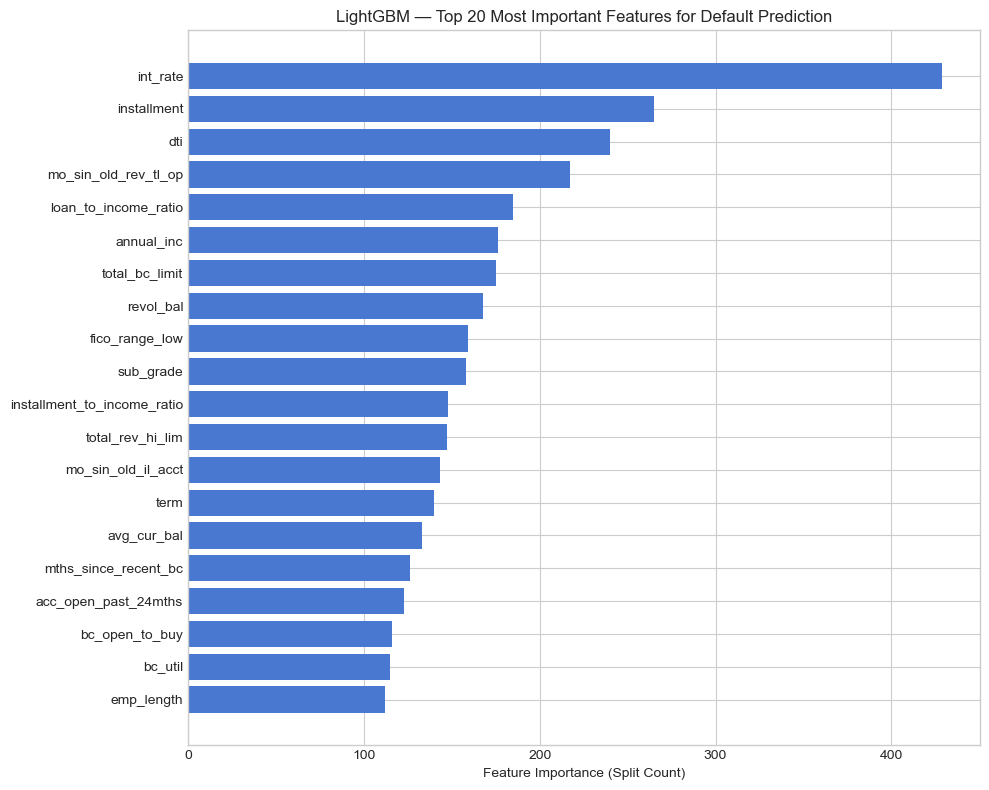

Top 10 features for default prediction:

             feature  importance
            int_rate         429
         installment         265
                 dti         240
mo_sin_old_rev_tl_op         217
loan_to_income_ratio         185
          annual_inc         176
      total_bc_limit         175
           revol_bal         168
      fico_range_low         159
           sub_grade         158


In [3]:
# Extract LightGBM feature importances
lgbm_importance = pd.DataFrame({
    "feature": X_test_scaled.columns,
    "importance": lgbm_model.feature_importances_
}).sort_values("importance", ascending=False)

# Plot top 20 most important features
top_features = lgbm_importance.head(20)

fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.barh(top_features["feature"], top_features["importance"],
               color=sns.color_palette("muted")[0])

ax.set_xlabel("Feature Importance (Split Count)")
ax.set_title("LightGBM — Top 20 Most Important Features for Default Prediction")
ax.invert_yaxis()

plt.tight_layout()
plt.show()

print("Top 10 features for default prediction:")
print()
print(lgbm_importance.head(10).to_string(index=False))

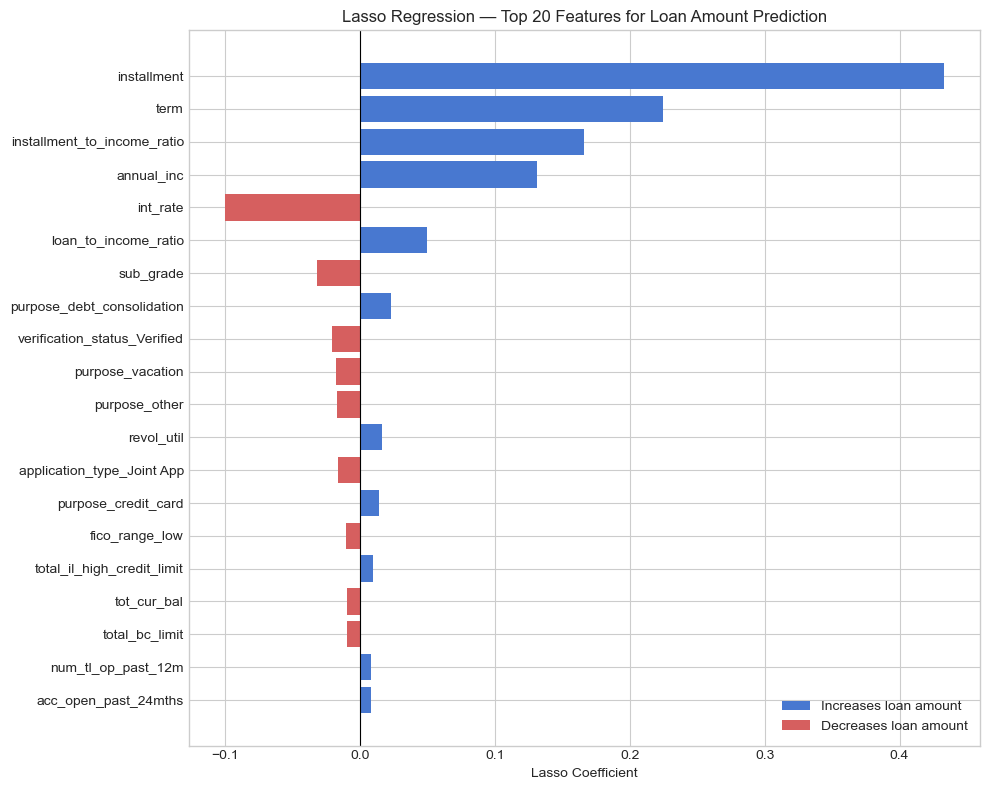

Top 10 features for loan amount prediction:

                     feature  coefficient
                 installment       0.4330
                        term       0.2246
 installment_to_income_ratio       0.1663
                  annual_inc       0.1311
                    int_rate      -0.1000
        loan_to_income_ratio       0.0498
                   sub_grade      -0.0314
  purpose_debt_consolidation       0.0232
verification_status_Verified      -0.0208
            purpose_vacation      -0.0177


In [4]:
# Extract Lasso coefficients as feature importance for regression
# We use absolute values since both positive and negative coefficients
# indicate strong influence — direction matters but magnitude measures importance
lasso_importance = pd.DataFrame({
    "feature": X_test_scaled.columns,
    "coefficient": lasso_model.coef_,
    "abs_coefficient": np.abs(lasso_model.coef_)
}).sort_values("abs_coefficient", ascending=False)

# Plot top 20 features — color coded by direction of effect
top_lasso = lasso_importance.head(20)

fig, ax = plt.subplots(figsize=(10, 8))

colors = [sns.color_palette("muted")[0] if c > 0
          else sns.color_palette("muted")[3]
          for c in top_lasso["coefficient"]]

ax.barh(top_lasso["feature"], top_lasso["coefficient"], color=colors)
ax.axvline(x=0, color="black", linewidth=0.8)
ax.set_xlabel("Lasso Coefficient")
ax.set_title("Lasso Regression — Top 20 Features for Loan Amount Prediction")
ax.invert_yaxis()

# Add legend explaining color coding
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=sns.color_palette("muted")[0], label="Increases loan amount"),
    Patch(facecolor=sns.color_palette("muted")[3], label="Decreases loan amount")
]
ax.legend(handles=legend_elements, loc="lower right")

plt.tight_layout()
plt.show()

print("Top 10 features for loan amount prediction:")
print()
print(lasso_importance[["feature", "coefficient"]].head(10).to_string(index=False))

## Section 2: Final Model Evaluation

We perform a comprehensive final evaluation of both selected models on
the held-out test set — data neither model has seen during training or tuning.

In [5]:
# Final classification evaluation — LightGBM
lgbm_prob = lgbm_model.predict_proba(X_test_scaled)[:, 1]
lgbm_pred = lgbm_model.predict(X_test_scaled)
lgbm_auc = roc_auc_score(y_test_class, lgbm_prob)

# Final regression evaluation — Lasso
lasso_pred_log = lasso_model.predict(X_test_scaled)
lasso_pred = np.clip(np.expm1(lasso_pred_log), 1000, 40000)
lasso_r2 = r2_score(y_test_reg, lasso_pred)
lasso_rmse = np.sqrt(mean_squared_error(y_test_reg, lasso_pred))
lasso_mae = mean_absolute_error(y_test_reg, lasso_pred)

print("Final Classification Model — LightGBM:")
print()
print(f"ROC-AUC : {lgbm_auc:.4f}")
print()
print(classification_report(y_test_class, lgbm_pred,
                            target_names=["Non-Default", "Default"]))
print()
print("Final Regression Model — Lasso:")
print()
print(f"R²   : {lasso_r2:.4f}")
print(f"RMSE : ${lasso_rmse:,.2f}")
print(f"MAE  : ${lasso_mae:,.2f}")

Final Classification Model — LightGBM:

ROC-AUC : 0.7740

              precision    recall  f1-score   support

 Non-Default       0.88      0.72      0.79    140299
     Default       0.42      0.68      0.52     42587

    accuracy                           0.71    182886
   macro avg       0.65      0.70      0.65    182886
weighted avg       0.77      0.71      0.73    182886


Final Regression Model — Lasso:

R²   : 0.9304
RMSE : $2,364.09
MAE  : $1,774.39


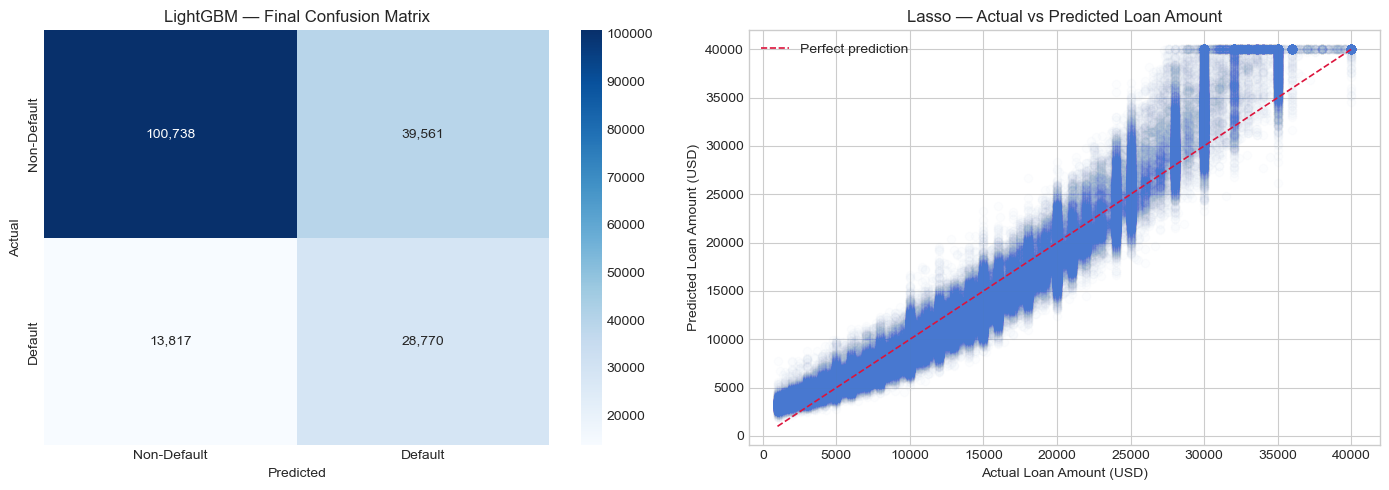

In [6]:
# Final confusion matrix for LightGBM
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test_class, lgbm_pred)
sns.heatmap(cm, annot=True, fmt=",", cmap="Blues", ax=axes[0],
            xticklabels=["Non-Default", "Default"],
            yticklabels=["Non-Default", "Default"])
axes[0].set_title("LightGBM — Final Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Actual vs predicted for Lasso regression
axes[1].scatter(y_test_reg, lasso_pred, alpha=0.01,
                color=sns.color_palette("muted")[0])
axes[1].plot([1000, 40000], [1000, 40000], color="crimson",
             linestyle="--", linewidth=1.2, label="Perfect prediction")
axes[1].set_xlabel("Actual Loan Amount (USD)")
axes[1].set_ylabel("Predicted Loan Amount (USD)")
axes[1].set_title("Lasso — Actual vs Predicted Loan Amount")
axes[1].legend()

plt.tight_layout()
plt.show()

## Section 3: Project Summary

### Problem Statement
Built an end-to-end machine learning pipeline on 2.26M real LendingClub loan
records to solve two production-realistic prediction problems:
- Default prediction (classification) using only application-time features
- Loan amount prediction (regression) based on borrower financial profile

### Data Pipeline
- Filtered 2.26M records to 915,420 outcome-known loans (2015-2018)
- Removed 44 high-missing columns, 16 data leakage columns
- Fixed outliers in annual_inc, dti, revol_util
- Engineered 5 domain-driven features including loan_to_income_ratio
  and credit_utilization_risk — both appeared in top 10 feature importances
- Applied StandardScaler and PCA (86 → 53 components, 95.4% variance retained)

### Statistical Validation
- T-test confirmed defaulters earn significantly less (p ≈ 0)
- Chi-square confirmed loan grade is strongly associated with default (p ≈ 0)
- ANOVA confirmed interest rate differs significantly across loan purposes (p ≈ 0)

### Classification Results

| Model | ROC-AUC | Default Recall |
|---|---|---|
| Logistic Regression | 0.7585 | 0.63 |
| Decision Tree | 0.7511 | 0.66 |
| Random Forest (tuned) | 0.7637 | 0.55 |
| XGBoost | 0.7741 | 0.67 |
| LightGBM | 0.7740 | 0.68 |

**Selected: LightGBM — AUC 0.7740, Default Recall 0.68**

### Regression Results

| Model | R² | RMSE |
|---|---|---|
| Linear Regression | 0.8054 | $3,952 |
| Ridge Regression | 0.8054 | $3,952 |
| Lasso Regression | 0.8070 | $3,936 |
| Lasso Final (clipped) | 0.9304 | $2,364 |

**Selected: Lasso — R² 0.9304, RMSE $2,364, MAE $1,774**

### Key Findings
1. Interest rate is the strongest default predictor — it encodes LendingClub's
   own risk assessment as a single powerful signal
2. Loan grade shows a perfect monotonic default rate from 7% (A) to 55% (G)
3. Engineered features loan_to_income_ratio and installment_to_income_ratio
   both ranked in top 10 feature importances, validating the feature engineering
4. All models converge near 0.76 AUC — consistent with published benchmarks
   on application-time-only feature sets for this dataset
5. Prediction clipping to platform limits ($1,000-$40,000) improved regression
   R² from 0.807 to 0.930 — a domain knowledge driven improvement

### Limitations and Future Work
- Gradient boosting AUC ceiling at 0.774 reflects genuine difficulty of
  default prediction from application-time features only
- External data (macroeconomic indicators, bureau tradeline data) would
  likely push AUC above 0.85
- Threshold optimization on the classifier could improve the precision-recall
  tradeoff for specific business risk appetites

In [8]:
print("Notebook 06 complete.")
print()
print("All models saved to models/:")
print("  classifier_lgbm.pkl   — LightGBM default predictor")
print("  classifier_xgb.pkl    — XGBoost default predictor")
print("  classifier_rf.pkl     — Random Forest default predictor")
print("  regressor_lasso.pkl   — Lasso loan amount predictor")
print("  scaler.pkl            — StandardScaler")
print("  pca.pkl               — PCA transformer")

Notebook 06 complete.

All models saved to models/:
  classifier_lgbm.pkl   — LightGBM default predictor
  classifier_xgb.pkl    — XGBoost default predictor
  classifier_rf.pkl     — Random Forest default predictor
  regressor_lasso.pkl   — Lasso loan amount predictor
  scaler.pkl            — StandardScaler
  pca.pkl               — PCA transformer
